In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hdbscan
from collections import Counter

In [3]:
N = 1000000
kappa_range = (np.linspace(-1, 1, 20))**3
#max_new = 0.115+0.003
#min_new = 0.115-0.003
#kappa_range = (kappa_range-kappa_range.min()) * (max_new - min_new) / 2 + min_new

max_new = 0.108021+0.003
min_new = 0.108021-0.003
kappa_range = (kappa_range-kappa_range.min()) * (max_new - min_new) / 2 + min_new

num_ensambles = 3000
M = np.empty((len(kappa_range), num_ensambles))
for n in range(num_ensambles):
    with open('results/{0}_{1}_rho_critical.p'.format(n, N), "rb") as f:
        mags = pickle.load(f)
        for k in range(len(kappa_range)):
            m = mags[k]
            M[k,n] = m

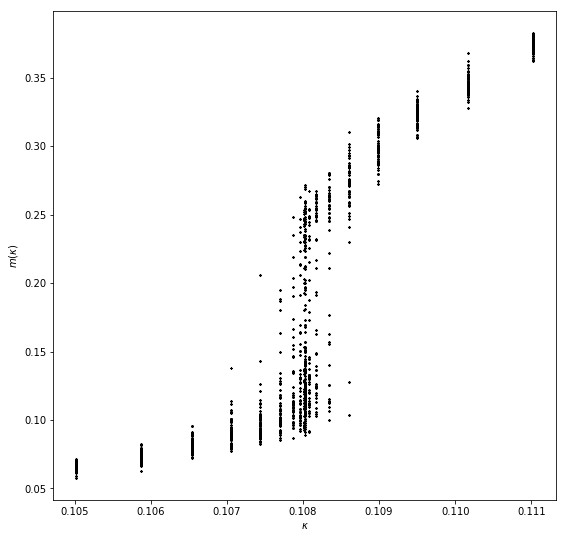

In [4]:
plt.figure(figsize=(9,9))
for n in range(num_ensambles):
    plt.plot(kappa_range, M[:, n], 'ko', ms=0.5)
plt.xlabel(r'$\kappa$')
plt.ylabel(r'$m(\kappa)$')
plt.show()

In [5]:
pairs = []

for k in range(len(kappa_range)):
    ms = M[k]
    md = ms[ms <=0.15]
    mu = ms[ms > 0.15]
    if md.size >= ms.size//4:
        pairs.append([kappa_range[k], np.mean(md)])
    if mu.size >= ms.size//4:
        pairs.append([kappa_range[k], np.mean(mu)])

In [9]:
pairs[0]

array([0.105021  , 0.06588895])

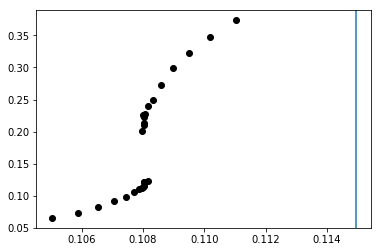

In [6]:
pairs = np.array(pairs)
plt.plot(*pairs.T, 'ko')
plt.axvline(0.11495)
plt.show()

In [9]:
P = np.round(M*2)

In [10]:
Pinfinito =  [np.mean(P[k, :]) for k in range(len(kappa_range))]

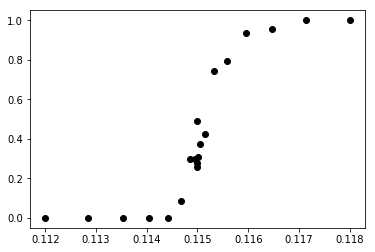

In [12]:
plt.plot(kappa_range, Pinfinito, 'ko')
plt.show()

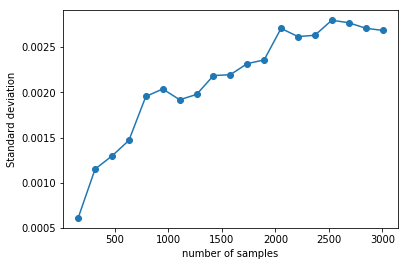

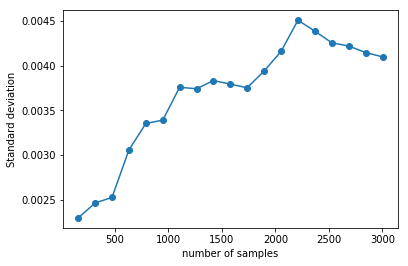

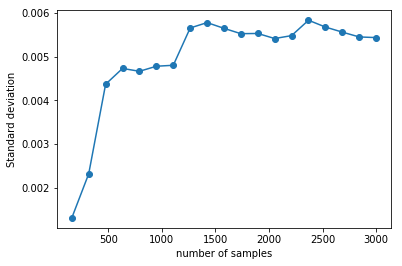

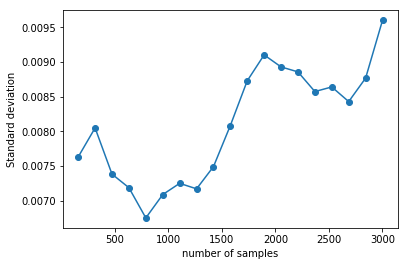

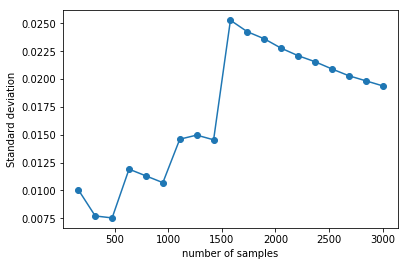

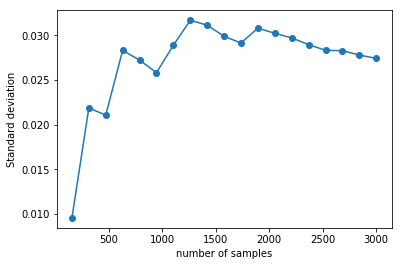

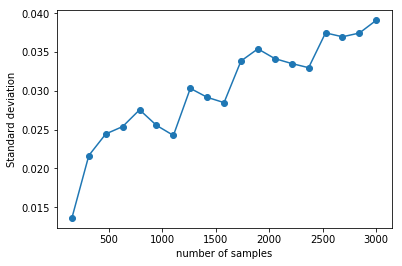

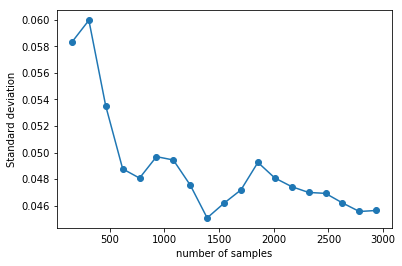

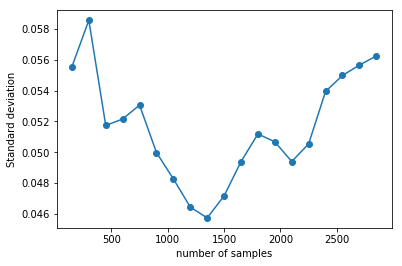

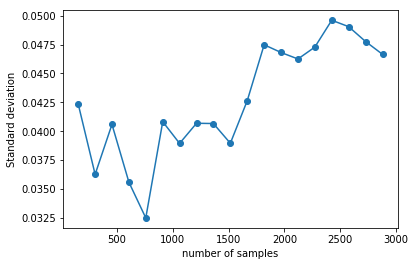

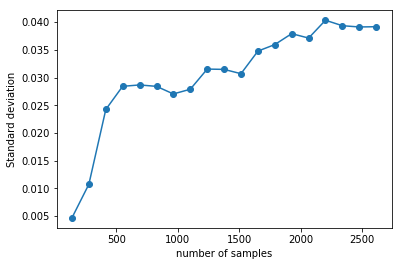

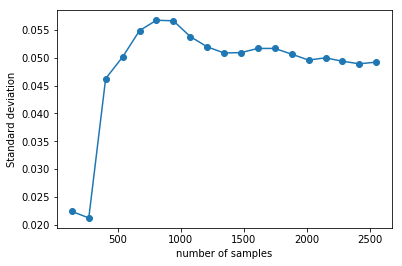

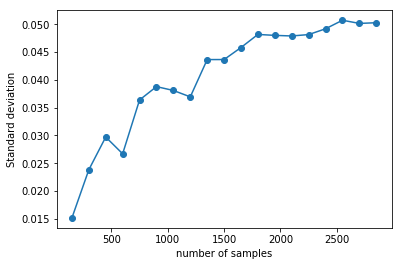

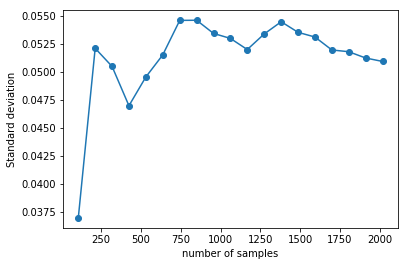

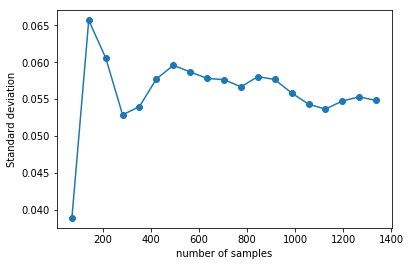

In [11]:
def print_mean_variance(m):
    bin_edges = [int(n) for n in np.linspace(0, m.size, 20, endpoint=True)]
    means = []
    stds = []
    N = []
    for i in bin_edges[1:]:
        means.append(np.mean(m[:(i+1)]))
        stds.append(np.std(m[:(i+1)]))
        N.append(i+1)
    return means, stds, N

for k in range(len(kappa_range)):
    ms = M[k]
    md = ms[ms <=0.25]
    mu = ms[ms > 0.25]
    if md.size >= ms.size//4:
        means, stds, Ns = print_mean_variance(md)
        plt.plot(Ns, stds, marker='o', ls='-')
        plt.xlabel("number of samples")
        plt.ylabel("Standard deviation")
        plt.show()

Counter({-1: 1535, 0: 1465})
0.06609684027303754
0.105021


/home/vladimir/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


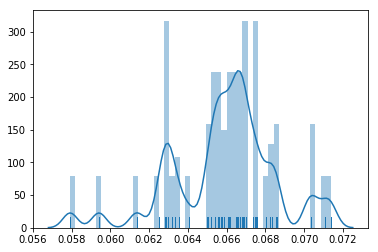

Counter({0: 1728, -1: 1272})
0.07119437037037038
0.10587214448170287


/home/vladimir/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


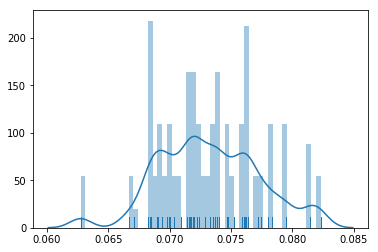

Counter({-1: 2239, 0: 761})
0.07934523390275952
0.10654483729406619


/home/vladimir/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


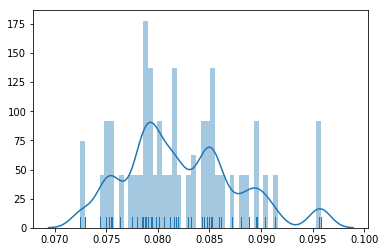

Counter({-1: 2391, 0: 609})
0.08950006403940887
0.10706007275112991


/home/vladimir/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


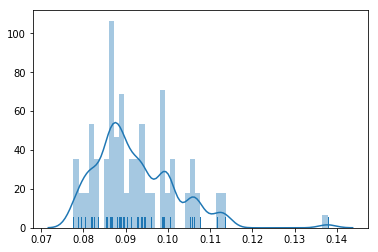

Counter({0: 2424, -1: 576})
0.0946047400990099
0.10743884516693396


/home/vladimir/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


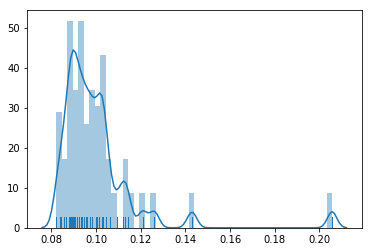

Counter({-1: 2209, 0: 791})
0.09862283059418459
0.1077021488555183


/home/vladimir/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


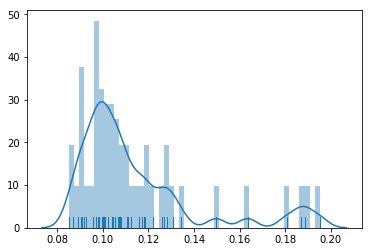

Counter({-1: 2112, 0: 888})
0.10972296283783783
0.10787097813092288


/home/vladimir/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


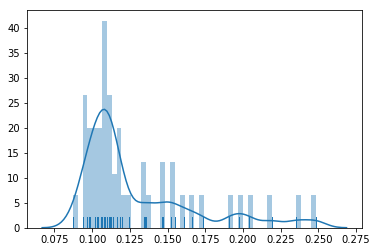

Counter({1: 2367, 0: 633})
0.22666086413902053
0.11987412420785808
0.10796632730718764


/home/vladimir/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


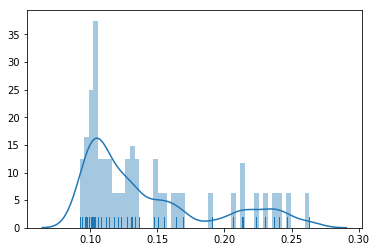

Counter({1: 1792, 0: 1208})
0.22988856788079468
0.11603660714285714
0.10800919069835253


/home/vladimir/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


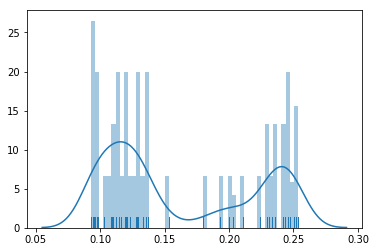

Counter({0: 1919, 1: 1081})
0.2203777012025902
0.12424116050026056
0.10802056261845751


/home/vladimir/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


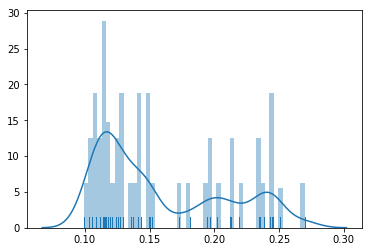

Counter({0: 2239, 1: 761})
0.12954326574363556
0.24062602102496713
0.1080214373815425


/home/vladimir/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


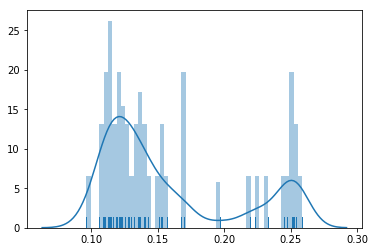

Counter({2: 1185, 0: 1152, 1: 663})
0.23555366666666672
0.14669974057315235
0.10556929873417721
0.10803280930164748


/home/vladimir/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


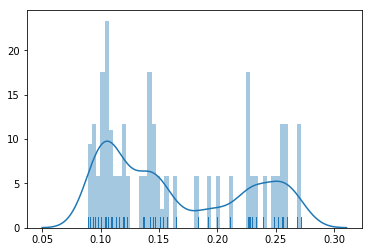

Counter({0: 1960, 1: 1040})
0.12181604489795919
0.22712224519230773
0.10807567269281237


/home/vladimir/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


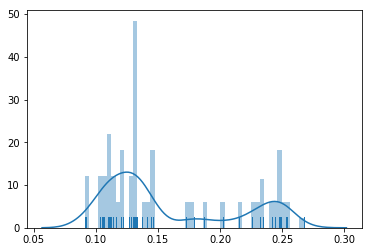

Counter({0: 1663, 1: 1337})
0.24617077390258568
0.12785191847419597
0.10817102186907714


/home/vladimir/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


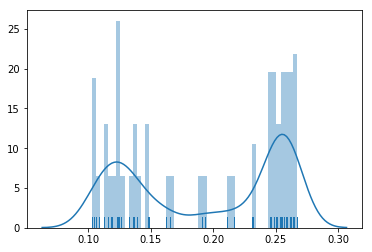

Counter({1: 2111, 0: 889})
0.2592602169587873
0.12958299775028123
0.1083398511444817


/home/vladimir/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


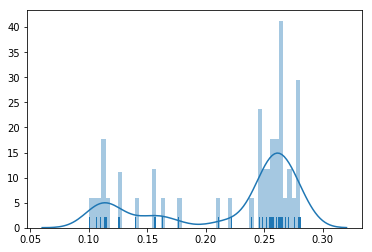

Counter({1: 1249, -1: 919, 0: 832})
0.27786826421136906
0.26240407692307693
0.10860315483306605


/home/vladimir/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


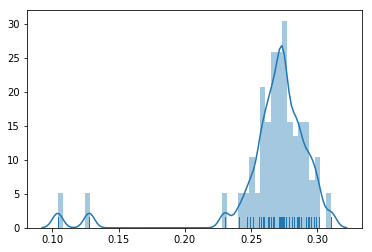

Counter({0: 2552, -1: 448})
0.2997474294670846
0.1089819272488701


/home/vladimir/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


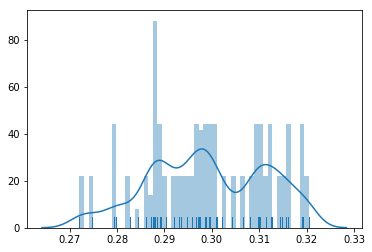

Counter({0: 1896, -1: 1104})
0.32456151054852317
0.10949716270593382


/home/vladimir/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


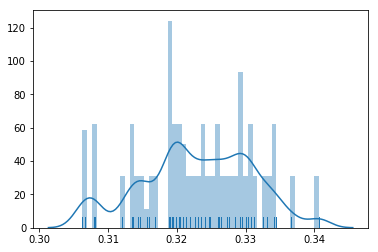

Counter({0: 1953, -1: 1047})
0.34690197183819765
0.11016985551829714


/home/vladimir/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


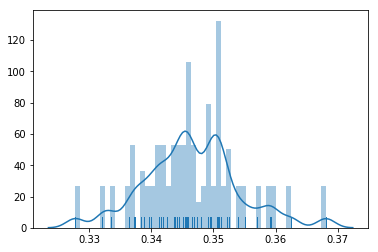

Counter({0: 2337, -1: 663})
0.3735647642276423
0.11102100000000001


/home/vladimir/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


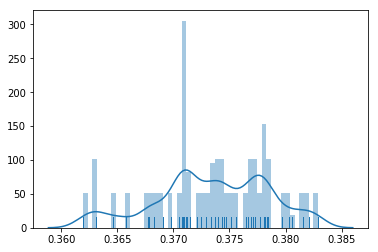

In [10]:
for k in range(len(kappa_range)):
    ms = M[k]
    clusterer = hdbscan.HDBSCAN(min_cluster_size=num_ensambles//5, min_samples=1, allow_single_cluster=True)
    clusterer.fit(ms.reshape(-1, 1))
    cter = Counter(clusterer.labels_) 
    print(cter)
    for l in cter:
        if l != -1:
            whr = np.where(clusterer.labels_ == l)
            print(np.mean(ms[whr]))
    print(kappa_range[k])
    sns.distplot(ms, rug=True, hist=True, bins=50)
    plt.show()